In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Global Style

In [3]:
plt.rcParams.update({
    "figure.facecolor"  : "#0d1117",
    "axes.facecolor"    : "#161b22",
    "axes.edgecolor"    : "#30363d",
    "axes.labelcolor"   : "white",
    "axes.titlecolor"   : "white",
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "xtick.color"       : "white",
    "ytick.color"       : "white",
    "text.color"        : "white",
    "grid.color"        : "#30363d",
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "legend.facecolor"  : "#161b22",
    "legend.edgecolor"  : "#30363d",
    "legend.labelcolor" : "white",
})

COLORS = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657",
          "#79c0ff", "#56d364", "#ff7b72", "#bc8cff", "#ffc680"]

month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# DATA LOADING

In [4]:
customers   = pd.read_csv("cleaned_customers.csv")
orders      = pd.read_csv("cleaned_orders.csv")
payments    = pd.read_csv("cleaned_payments.csv")
products    = pd.read_csv("cleaned_products.csv")
order_items = pd.read_csv("cleaned_order_items.csv")

date_cols = ["order_purchase_timestamp","order_approved_at",
             "order_delivered_carrier_date","order_delivered_customer_date",
             "order_estimated_delivery_date"]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], dayfirst=True, errors="coerce")

order_items["price"]      = pd.to_numeric(order_items["price"],      errors="coerce")
payments["payment_value"] = pd.to_numeric(payments["payment_value"], errors="coerce")
payments["payment_installments"] = pd.to_numeric(payments["payment_installments"], errors="coerce")

print("All datasets loaded successfully.\n")

All datasets loaded successfully.



#  LEVEL 1 — BASIC PROBLEMS

Q1 : Top 10 cities by customer count

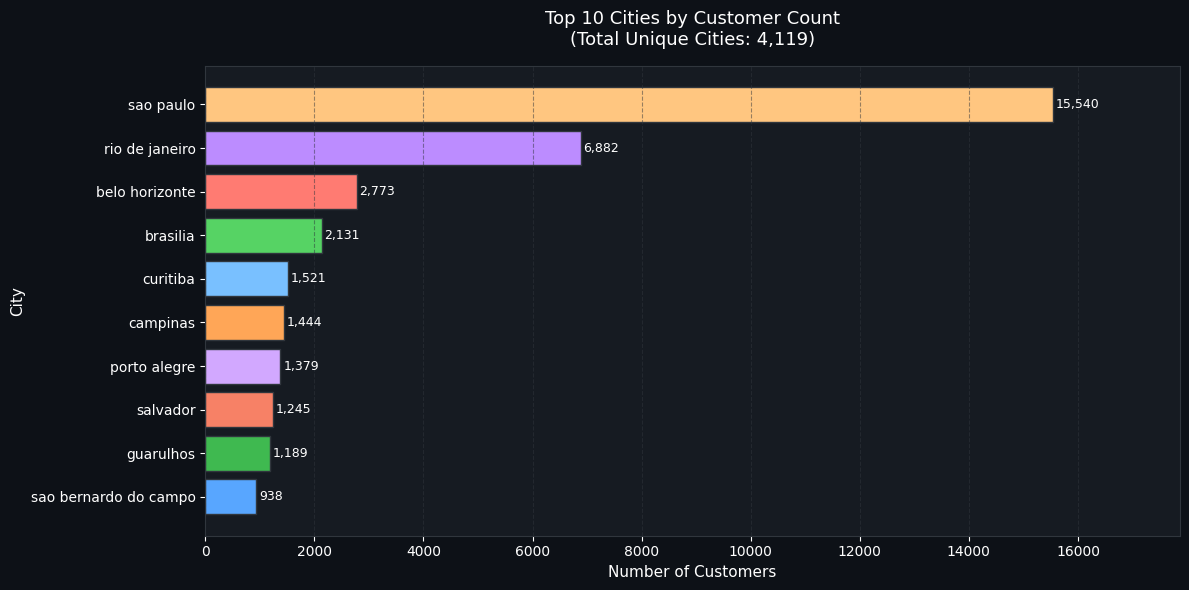

In [ ]:
unique_cities = customers["customer_city"].drop_duplicates().reset_index(drop=True)
top_cities = (
    customers["customer_city"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_cities.columns = ["customer_city", "count"]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cities["customer_city"][::-1],
               top_cities["count"][::-1],
               color=COLORS[:10], edgecolor="#30363d")
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9, color='white')
ax.set_title(f"Top 10 Cities by Customer Count\n(Total Unique Cities: {len(unique_cities):,})", pad=15)
ax.set_xlabel("Number of Customers")
ax.set_ylabel("City")
ax.grid(axis='x')
ax.set_xlim(0, top_cities["count"].max() * 1.15)
plt.tight_layout()
plt.savefig("unique_cities.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q2 : Orders placed in 2017

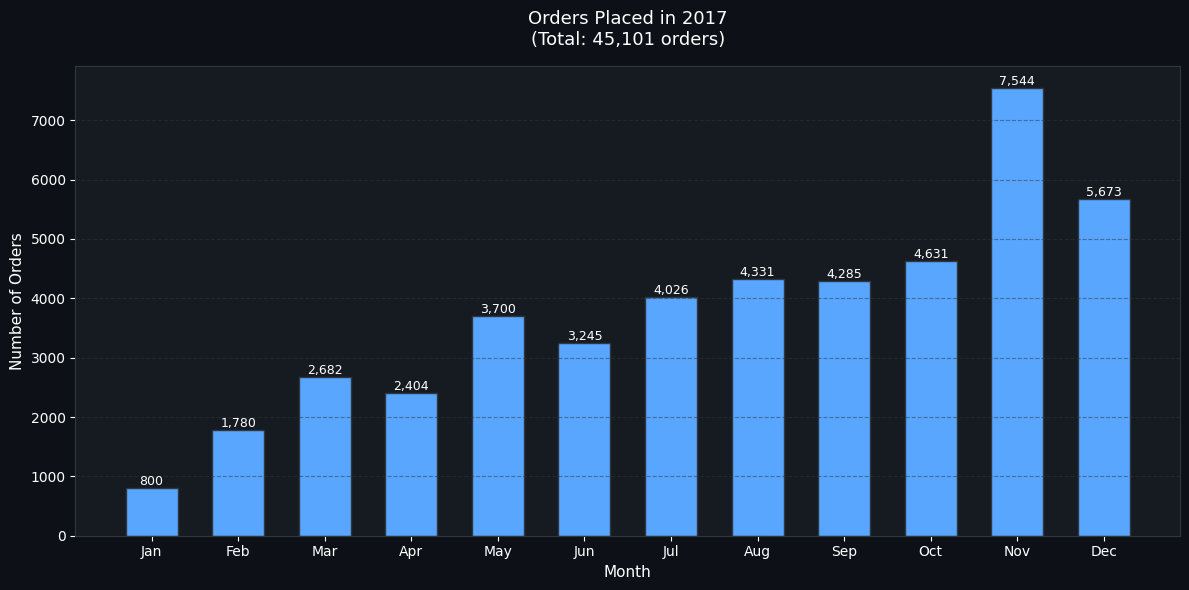

In [ ]:
orders_2017 = orders[orders["order_purchase_timestamp"].dt.year == 2017].copy()
orders_2017["month"] = orders_2017["order_purchase_timestamp"].dt.month
monthly_2017 = orders_2017.groupby("month")["order_id"].count().reset_index()
monthly_2017.columns = ["month", "order_count"]
monthly_2017["month_name"] = monthly_2017["month"].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(monthly_2017["month_name"], monthly_2017["order_count"],
              color=COLORS[0], edgecolor="#30363d", width=0.6)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, color='white')
ax.set_title(f"Orders Placed in 2017\n(Total: {monthly_2017['order_count'].sum():,} orders)", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.grid(axis='y')
plt.tight_layout()
plt.savefig("orders_2017.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q3 : Total sales per category (Top 15)

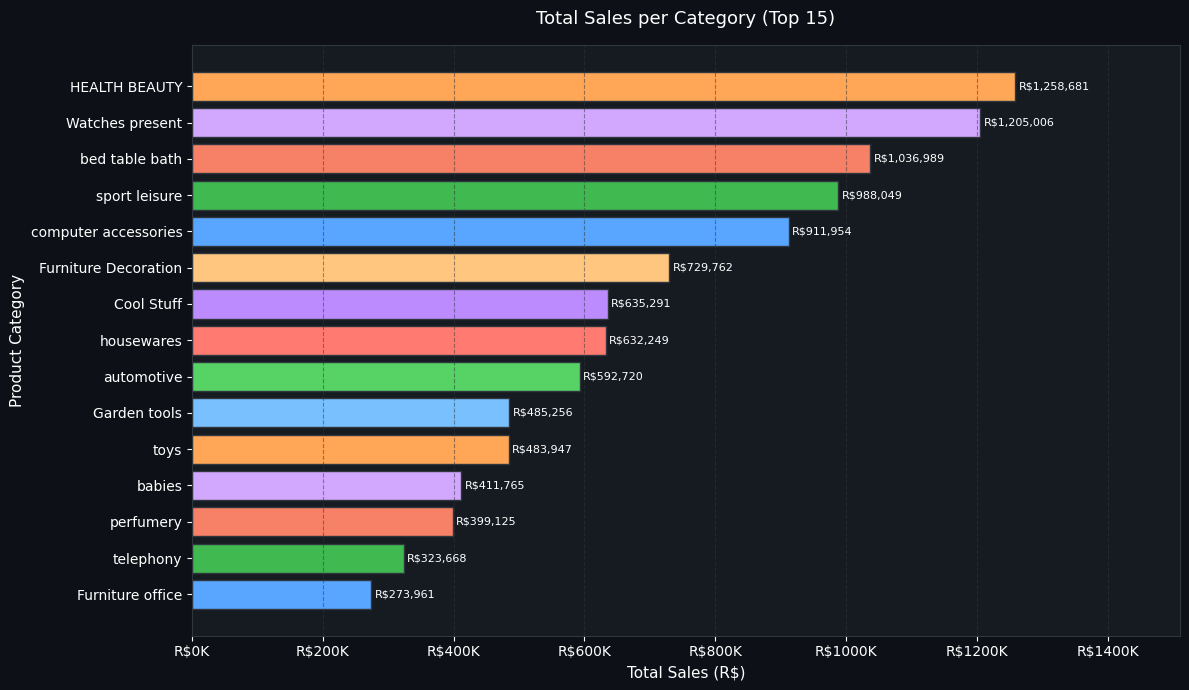

In [ ]:
sales_by_category = (
    order_items
    .merge(products[["product_id","product_category"]], on="product_id", how="left")
    .groupby("product_category", as_index=False)["price"].sum()
    .rename(columns={"price":"total_sales"})
    .sort_values("total_sales", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(sales_by_category["product_category"][::-1],
               sales_by_category["total_sales"][::-1],
               color=COLORS * 2, edgecolor="#30363d")
for bar in bars:
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R${bar.get_width():,.0f}', va='center', fontsize=8, color='white')
ax.set_title("Total Sales per Category (Top 15)", pad=15)
ax.set_xlabel("Total Sales (R$)")
ax.set_ylabel("Product Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.grid(axis='x')
ax.set_xlim(0, sales_by_category["total_sales"].max() * 1.2)
plt.tight_layout()
plt.savefig("sales_per_category.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q4 : Installment vs Non-Installment payments

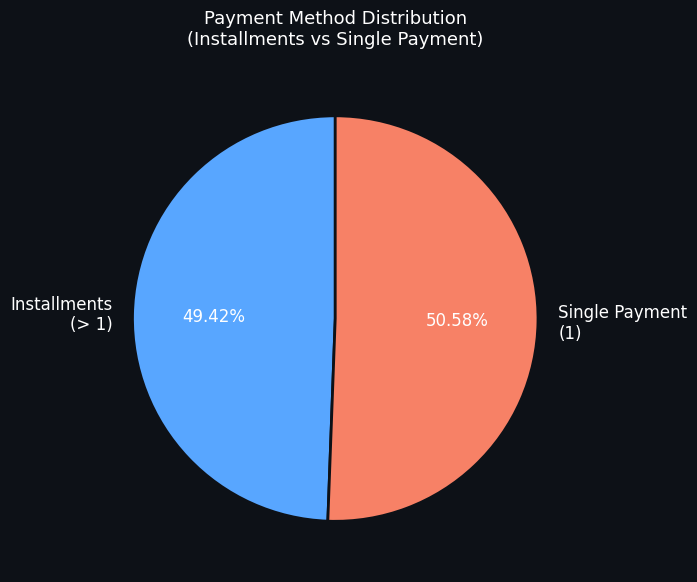

In [ ]:
installment     = (payments["payment_installments"] > 1).sum()
non_installment = (payments["payment_installments"] <= 1).sum()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [installment, non_installment],
    labels=["Installments\n(> 1)", "Single Payment\n(1)"],
    autopct="%1.2f%%",
    colors=[COLORS[0], COLORS[2]],
    startangle=90,
    wedgeprops={"edgecolor": "#0d1117", "linewidth": 2},
    textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color("white")
ax.set_title("Payment Method Distribution\n(Installments vs Single Payment)", pad=15)
plt.tight_layout()
plt.savefig("installment_pct.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q5 : Customers per state

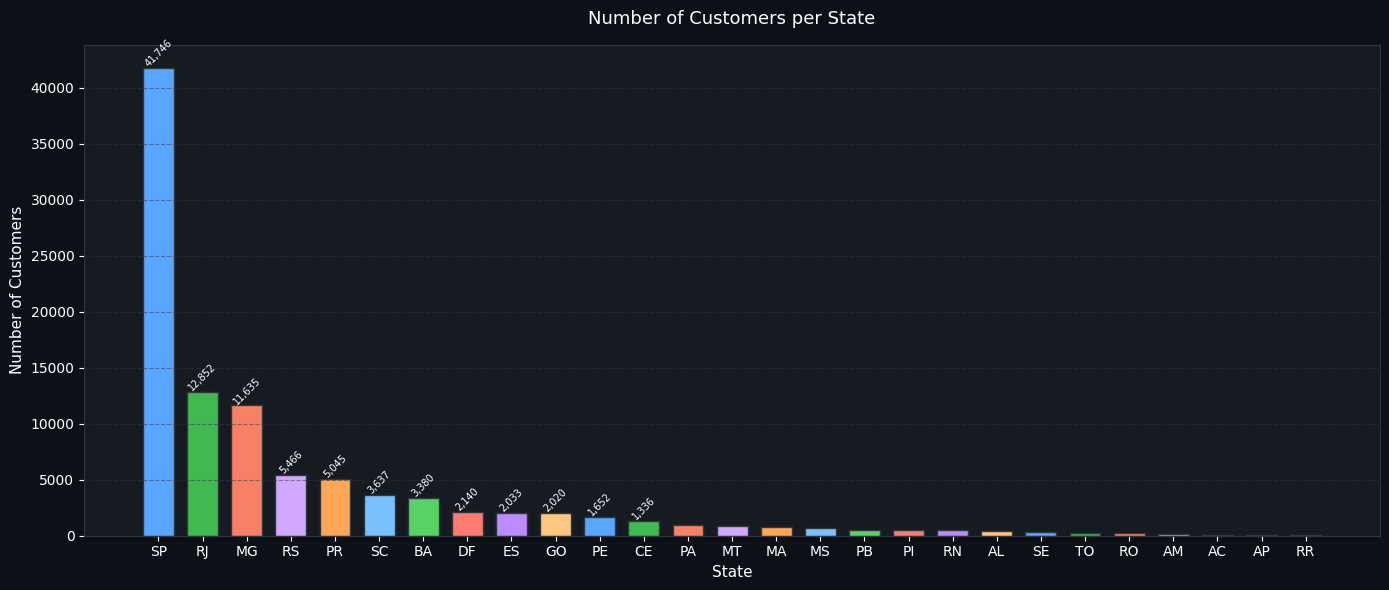

In [ ]:
customers_by_state = (
    customers.groupby("customer_state", as_index=False)["customer_id"].count()
    .rename(columns={"customer_id":"customer_count"})
    .sort_values("customer_count", ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(customers_by_state["customer_state"],
              customers_by_state["customer_count"],
              color=COLORS * 5, edgecolor="#30363d", width=0.7)
for bar in bars:
    if bar.get_height() > 1000:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{int(bar.get_height()):,}', ha='center', fontsize=7,
                color='white', rotation=45)
ax.set_title("Number of Customers per State", pad=15)
ax.set_xlabel("State")
ax.set_ylabel("Number of Customers")
ax.grid(axis='y')
plt.tight_layout()
plt.savefig("customers_per_state.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

#  LEVEL 2 — INTERMEDIATE PROBLEMS

Q1 : Orders per month in 2018

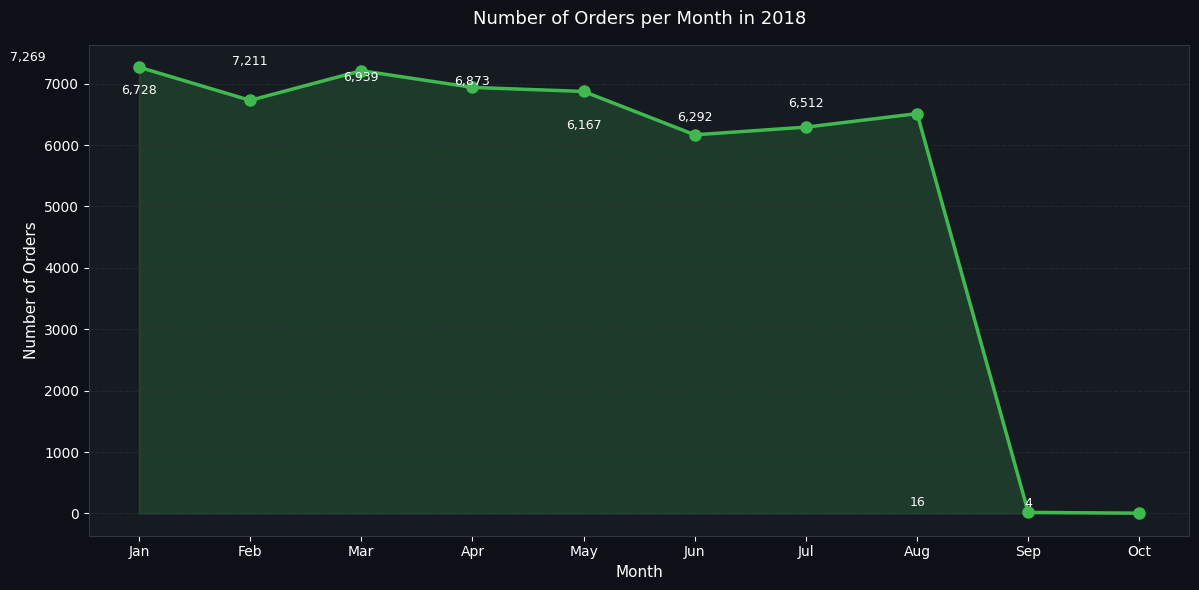

In [ ]:
orders_2018 = orders[orders["order_purchase_timestamp"].dt.year == 2018].copy()
orders_2018["month"] = orders_2018["order_purchase_timestamp"].dt.month
monthly_2018 = orders_2018.groupby("month")["order_id"].count().reset_index()
monthly_2018.columns = ["month", "order_count"]
monthly_2018["month_name"] = monthly_2018["month"].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_2018["month_name"], monthly_2018["order_count"],
        color=COLORS[1], marker='o', linewidth=2.5, markersize=8)
ax.fill_between(monthly_2018["month_name"], monthly_2018["order_count"],
                alpha=0.2, color=COLORS[1])
for i, row in monthly_2018.iterrows():
    ax.text(i - monthly_2018["month"].min(), row["order_count"] + 100,
            f'{int(row["order_count"]):,}', ha='center', fontsize=9, color='white')
ax.set_title("Number of Orders per Month in 2018", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.grid(axis='y')
plt.tight_layout()
plt.savefig("orders_per_month_2018.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q2 : Avg products per order by city (Top 15)

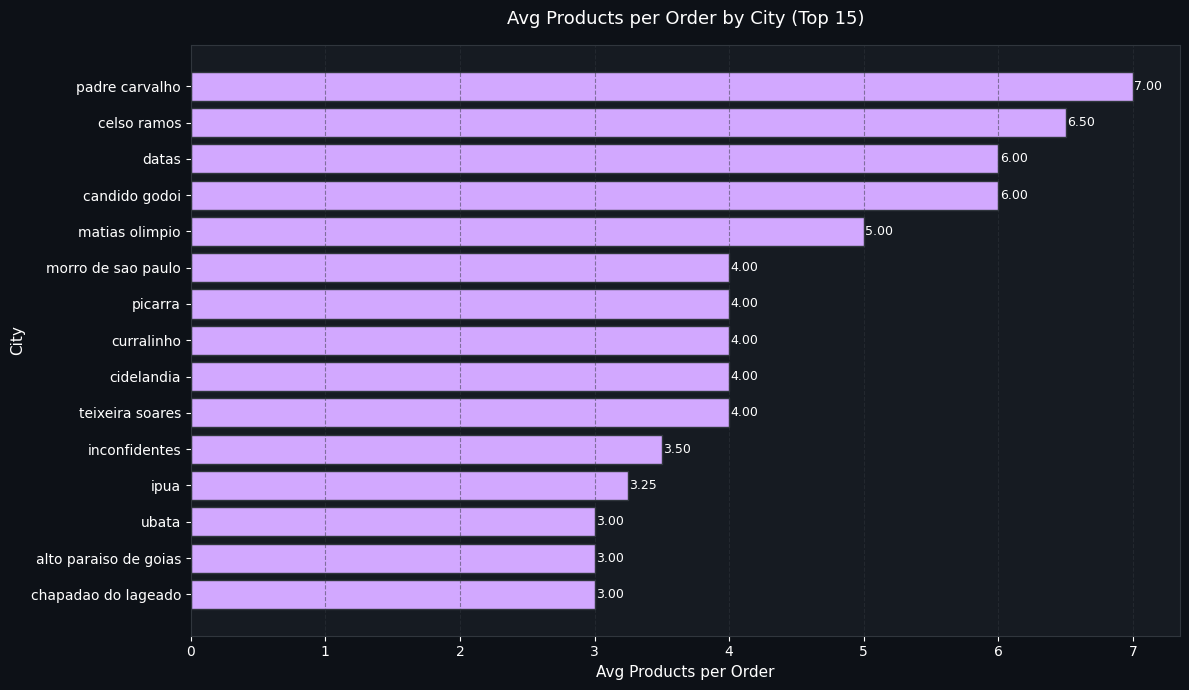

In [ ]:
order_product_count = (
    order_items.groupby("order_id", as_index=False)["product_id"].count()
    .rename(columns={"product_id":"product_count"})
)
avg_products_by_city = (
    orders[["order_id","customer_id"]]
    .merge(order_product_count, on="order_id", how="left")
    .merge(customers[["customer_id","customer_city"]], on="customer_id", how="left")
    .groupby("customer_city", as_index=False)["product_count"].mean()
    .rename(columns={"product_count":"avg_products_per_order"})
    .sort_values("avg_products_per_order", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(avg_products_by_city["customer_city"][::-1],
               avg_products_by_city["avg_products_per_order"][::-1],
               color=COLORS[3], edgecolor="#30363d")
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9, color='white')
ax.set_title("Avg Products per Order by City (Top 15)", pad=15)
ax.set_xlabel("Avg Products per Order")
ax.set_ylabel("City")
ax.grid(axis='x')
plt.tight_layout()
plt.savefig("avg_products_per_city.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q3 : Revenue % by category (Top 10)

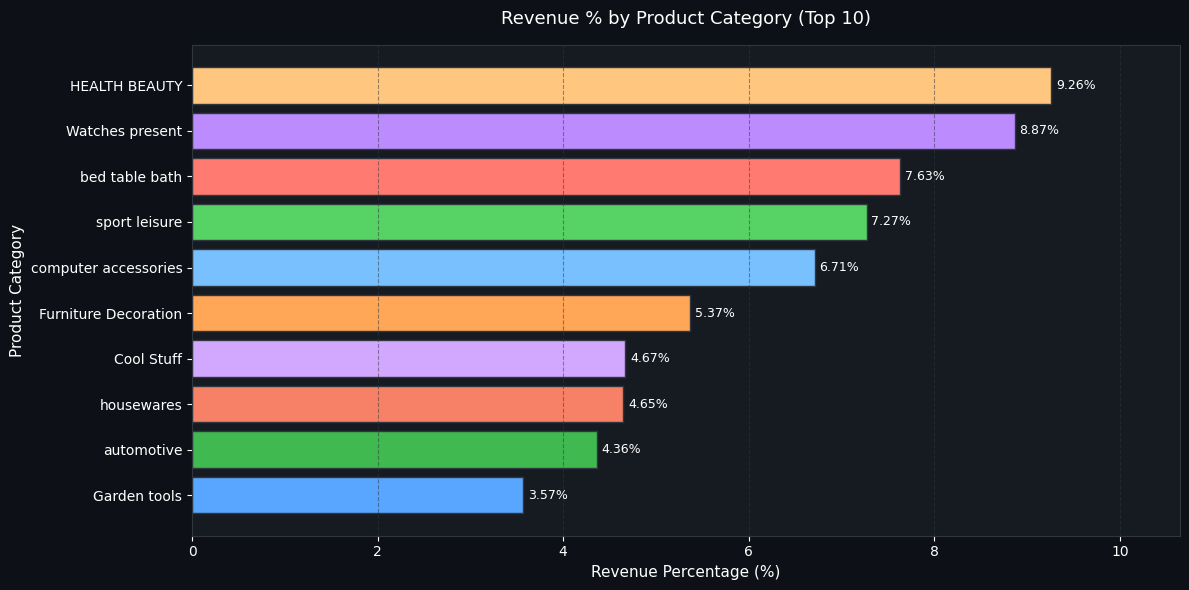

In [ ]:
revenue_by_category = (
    order_items
    .merge(products[["product_id","product_category"]], on="product_id", how="left")
    .groupby("product_category", as_index=False)["price"].sum()
)
total_revenue = revenue_by_category["price"].sum()
revenue_by_category["revenue_pct"] = (
    revenue_by_category["price"] / total_revenue * 100
).round(2)
revenue_by_category = (
    revenue_by_category
    .drop(columns="price")
    .sort_values("revenue_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    revenue_by_category["product_category"][::-1],
    revenue_by_category["revenue_pct"][::-1],
    color=COLORS[:10], edgecolor="#30363d"
)
for bar in bars:
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}%',
            va='center', fontsize=9, color='white')
ax.set_title("Revenue % by Product Category (Top 10)", pad=15)
ax.set_xlabel("Revenue Percentage (%)")
ax.set_ylabel("Product Category")
ax.set_xlim(0, revenue_by_category["revenue_pct"].max() * 1.15)
ax.grid(axis='x')
plt.tight_layout()
plt.savefig("revenue_pct_category.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q4 : Price vs Times Purchased (scatter + trend line)

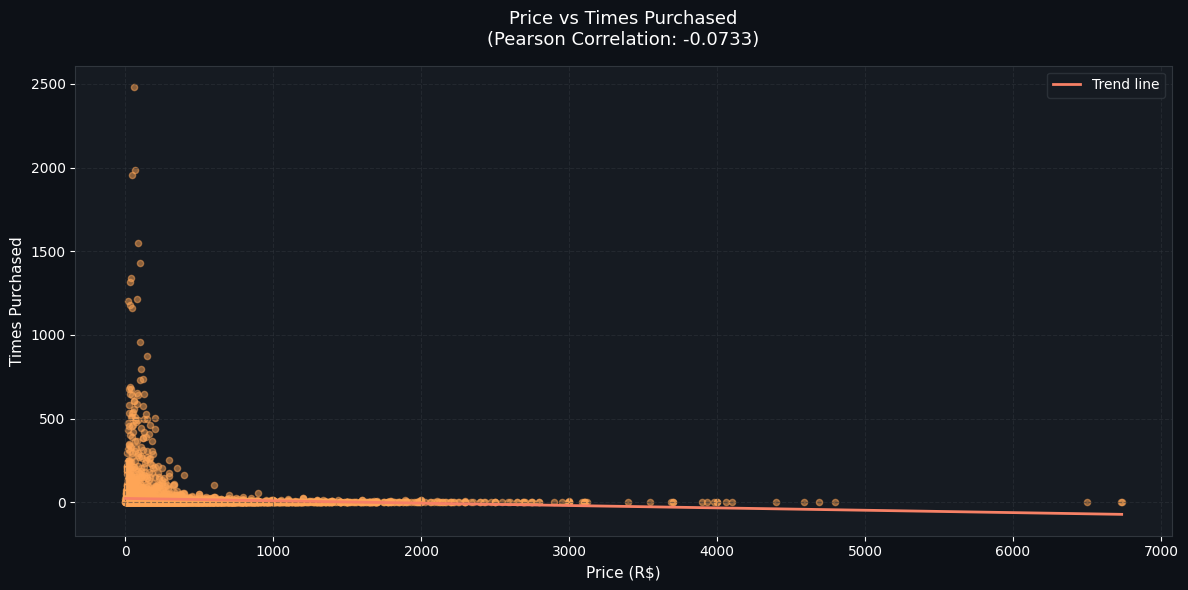

In [ ]:
price_vs_purchases = (
    order_items.groupby("price", as_index=False)["product_id"].count()
    .rename(columns={"product_id":"times_purchased"})
    .sort_values("price")
    .reset_index(drop=True)
)
price_vs_purchases["price"]           = price_vs_purchases["price"].round(2)
price_vs_purchases["times_purchased"] = price_vs_purchases["times_purchased"].astype(int)

# Correlation using Pandas only
correlation = price_vs_purchases["price"].corr(price_vs_purchases["times_purchased"])

# Trend line using Pandas only
x      = price_vs_purchases["price"]
y      = price_vs_purchases["times_purchased"]
x_mean = x.mean()
y_mean = y.mean()
slope     = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
intercept = y_mean - slope * x_mean
trend_y   = slope * x + intercept

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(x, y, color=COLORS[4], alpha=0.5, s=20)
ax.plot(x, trend_y, color=COLORS[2], linewidth=2, label="Trend line")
ax.set_title(f"Price vs Times Purchased\n(Pearson Correlation: {correlation:.4f})", pad=15)
ax.set_xlabel("Price (R$)")
ax.set_ylabel("Times Purchased")
ax.legend()
ax.grid()
plt.tight_layout()
plt.savefig("price_vs_purchases.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q5 : Top 15 sellers by revenue

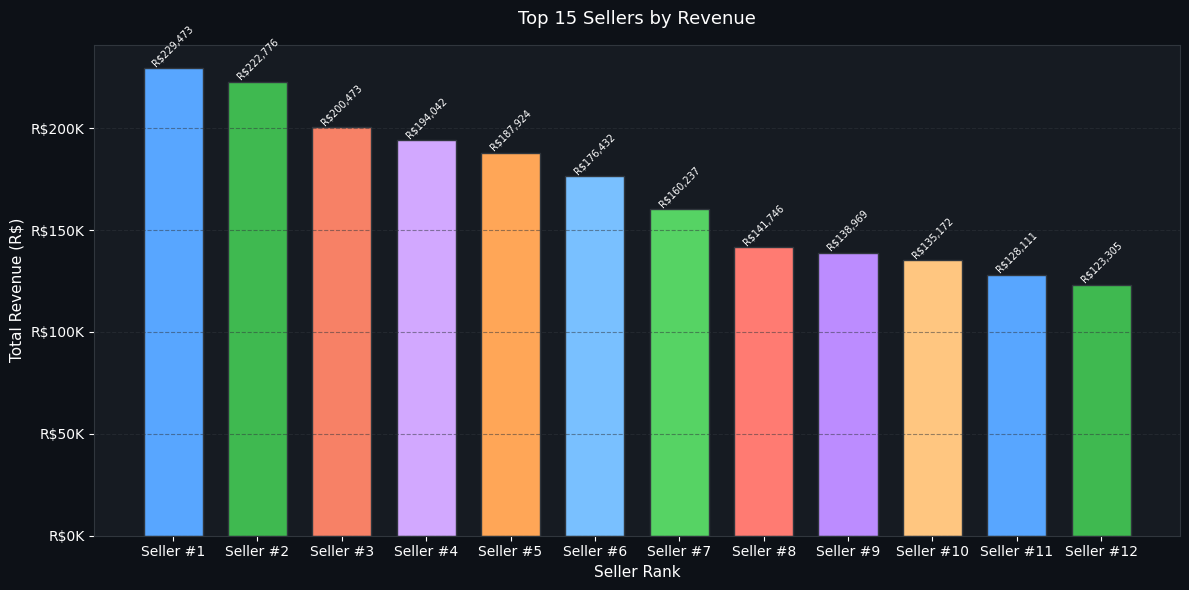

In [ ]:
seller_revenue = (
    order_items.groupby("seller_id", as_index=False)["price"].sum()
    .rename(columns={"price":"revenue"})
    .sort_values("revenue", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
seller_revenue["seller_rank"]  = seller_revenue.index + 1
seller_revenue["seller_label"] = "Seller #" + seller_revenue["seller_rank"].astype(str)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(seller_revenue["seller_label"], seller_revenue["revenue"],
              color=COLORS * 2, edgecolor="#30363d", width=0.7)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'R${bar.get_height():,.0f}', ha='center', fontsize=7,
            color='white', rotation=45)
ax.set_title("Top 15 Sellers by Revenue", pad=15)
ax.set_xlabel("Seller Rank")
ax.set_ylabel("Total Revenue (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax.grid(axis='y')
plt.tight_layout()
plt.savefig("seller_revenue.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

#  LEVEL 3 — ADVANCED PROBLEMS

Q1 : Moving average (Top 5 most active customers)

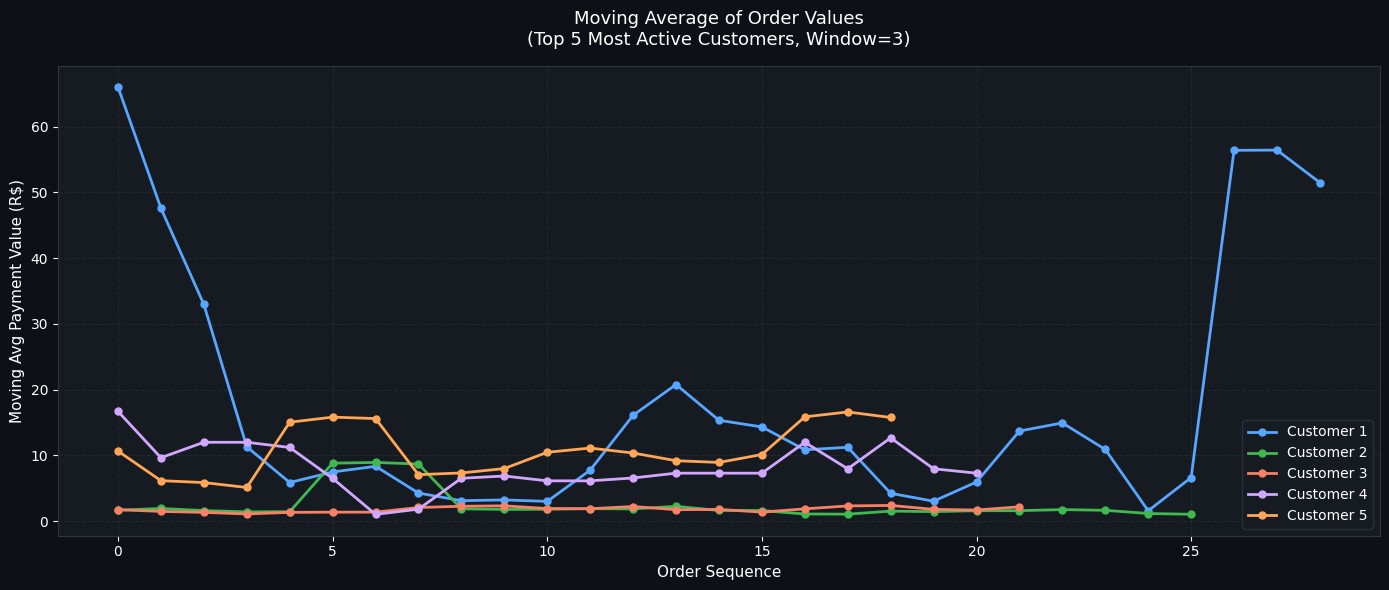

In [ ]:
order_payment = (
    orders[["order_id","customer_id","order_purchase_timestamp"]]
    .merge(payments[["order_id","payment_value"]], on="order_id", how="left")
    .sort_values(["customer_id","order_purchase_timestamp"])
)
order_payment["moving_avg"] = (
    order_payment.groupby("customer_id")["payment_value"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)
top5_customers = (
    order_payment.groupby("customer_id")["payment_value"]
    .count()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
for i, cust in enumerate(top5_customers):
    df_cust = order_payment[order_payment["customer_id"] == cust].reset_index(drop=True)
    ax.plot(df_cust.index, df_cust["moving_avg"],
            marker='o', linewidth=2, markersize=5,
            color=COLORS[i], label=f"Customer {i+1}")
ax.set_title("Moving Average of Order Values\n(Top 5 Most Active Customers, Window=3)", pad=15)
ax.set_xlabel("Order Sequence")
ax.set_ylabel("Moving Avg Payment Value (R$)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.savefig("moving_avg.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q2 : Cumulative sales per month for each year

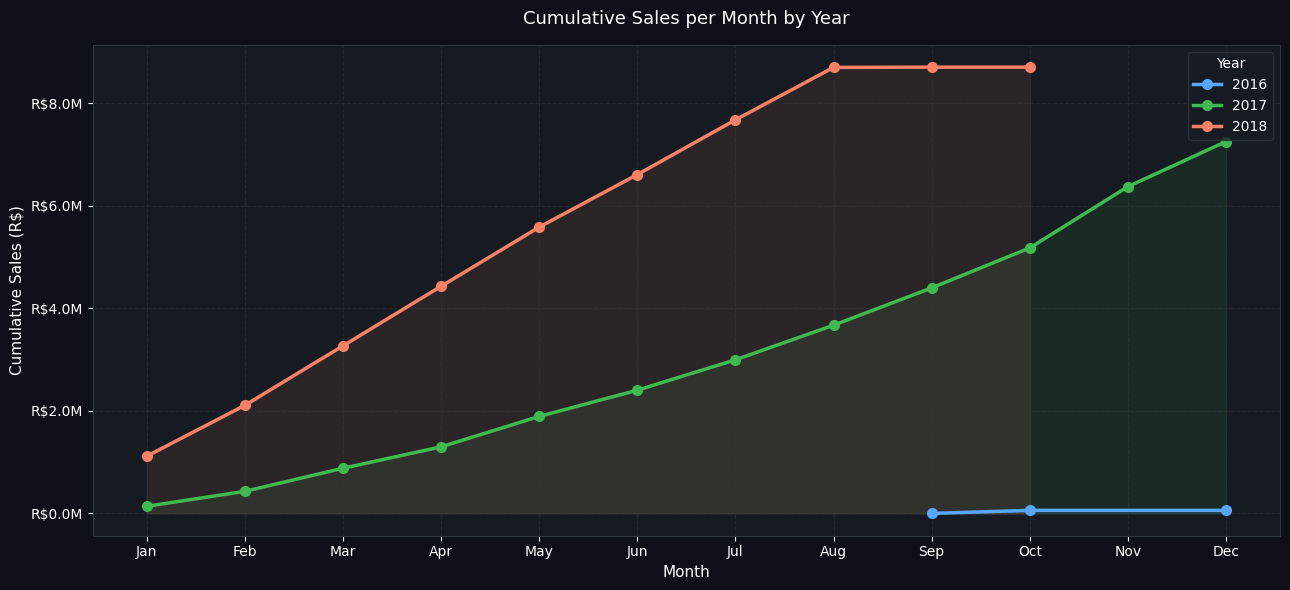

In [ ]:
monthly_sales = (
    orders[["order_id","order_purchase_timestamp"]]
    .merge(payments[["order_id","payment_value"]], on="order_id", how="left")
)
monthly_sales["year"]  = monthly_sales["order_purchase_timestamp"].dt.year
monthly_sales["month"] = monthly_sales["order_purchase_timestamp"].dt.month

monthly_agg = (
    monthly_sales.groupby(["year","month"], as_index=False)["payment_value"].sum()
    .sort_values(["year","month"]).reset_index(drop=True)
)
monthly_agg["cumulative_sales"] = (
    monthly_agg.groupby("year")["payment_value"].cumsum().round(2)
)
monthly_agg["year"]  = monthly_agg["year"].astype(int)
monthly_agg["month"] = monthly_agg["month"].astype(int)

fig, ax = plt.subplots(figsize=(13, 6))
for i, yr in enumerate(sorted(monthly_agg["year"].unique())):
    df_yr = monthly_agg[monthly_agg["year"] == yr]
    ax.plot(df_yr["month"], df_yr["cumulative_sales"],
            marker='o', linewidth=2.5, markersize=7,
            color=COLORS[i], label=str(yr))
    ax.fill_between(df_yr["month"], df_yr["cumulative_sales"],
                    alpha=0.1, color=COLORS[i])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title("Cumulative Sales per Month by Year", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Cumulative Sales (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.legend(title="Year")
ax.grid()
plt.tight_layout()
plt.savefig("cumulative_sales.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q3 : Year-over-year growth rate

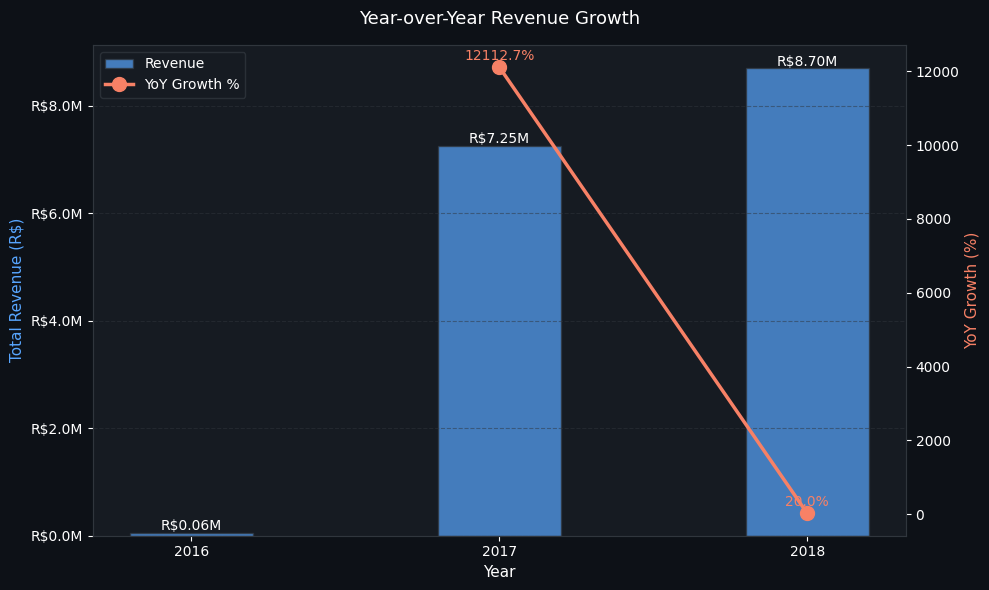

In [ ]:
yearly_sales = (
    orders[["order_id","order_purchase_timestamp"]]
    .merge(payments[["order_id","payment_value"]], on="order_id", how="left")
)
yearly_sales["year"] = yearly_sales["order_purchase_timestamp"].dt.year
yearly_agg = (
    yearly_sales.groupby("year", as_index=False)["payment_value"].sum()
    .rename(columns={"payment_value":"revenue"})
    .sort_values("year").reset_index(drop=True)
)
yearly_agg["year"]       = yearly_agg["year"].astype(int)
yearly_agg["yoy_growth"] = yearly_agg["revenue"].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.bar(yearly_agg["year"].astype(str), yearly_agg["revenue"],
        color=COLORS[0], alpha=0.7, edgecolor="#30363d", width=0.4, label="Revenue")
ax2.plot(yearly_agg["year"].astype(str), yearly_agg["yoy_growth"],
         color=COLORS[2], marker='o', linewidth=2.5, markersize=10, label="YoY Growth %")
for i, row in yearly_agg.iterrows():
    ax1.text(i, row["revenue"] + 50000, f'R${row["revenue"]/1e6:.2f}M',
             ha='center', fontsize=10, color='white')
    if pd.notna(row["yoy_growth"]):
        ax2.text(i, row["yoy_growth"] + 200, f'{row["yoy_growth"]:.1f}%',
                 ha='center', fontsize=10, color=COLORS[2])
ax1.set_title("Year-over-Year Revenue Growth", pad=15)
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Revenue (R$)", color=COLORS[0])
ax2.set_ylabel("YoY Growth (%)", color=COLORS[2])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.grid(axis='y')
plt.tight_layout()
plt.savefig("yoy_growth.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q4 : Retention rate

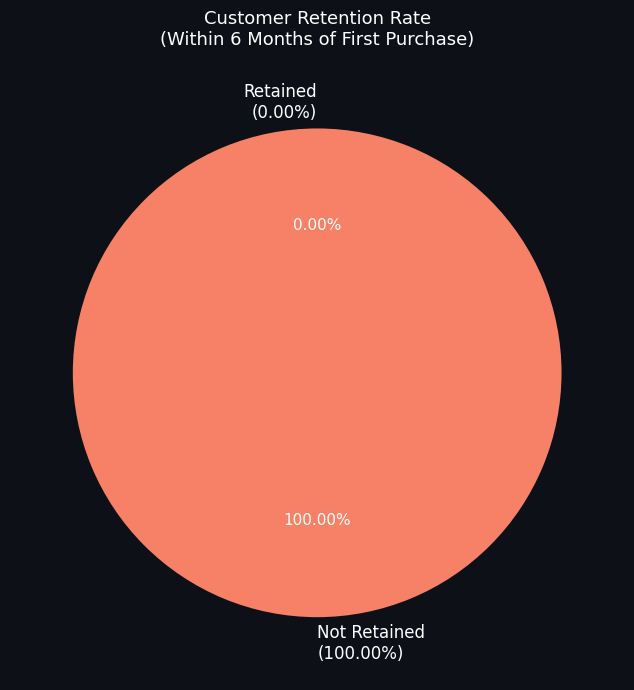

In [5]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], dayfirst=True
)

first_purchase = (
    orders
    .groupby("customer_id", as_index=False)["order_purchase_timestamp"]
    .min()
    .rename(columns={"order_purchase_timestamp": "first_purchase_date"})
)

merged = orders.merge(
    first_purchase, on="customer_id", how="left"
)

repeat_buyers = merged[
    (merged["order_purchase_timestamp"] > merged["first_purchase_date"]) &
    (merged["order_purchase_timestamp"] <= merged["first_purchase_date"] + pd.DateOffset(months=6))
]["customer_id"].nunique()

total_customers = first_purchase["customer_id"].nunique()
retention_rate  = (repeat_buyers / total_customers) * 100
churned_rate    = 100 - retention_rate

# Visualization
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    [retention_rate, churned_rate],
    labels=[f"Retained\n({retention_rate:.2f}%)",
            f"Not Retained\n({churned_rate:.2f}%)"],
    autopct="%1.2f%%",
    colors=[COLORS[1], COLORS[2]],
    startangle=90,
    wedgeprops={"edgecolor": "#0d1117", "linewidth": 2},
    textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_color("white")
ax.set_title("Customer Retention Rate\n(Within 6 Months of First Purchase)", pad=15)
plt.tight_layout()
plt.savefig("retention_rate.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

Q5 : Top 3 spenders per year

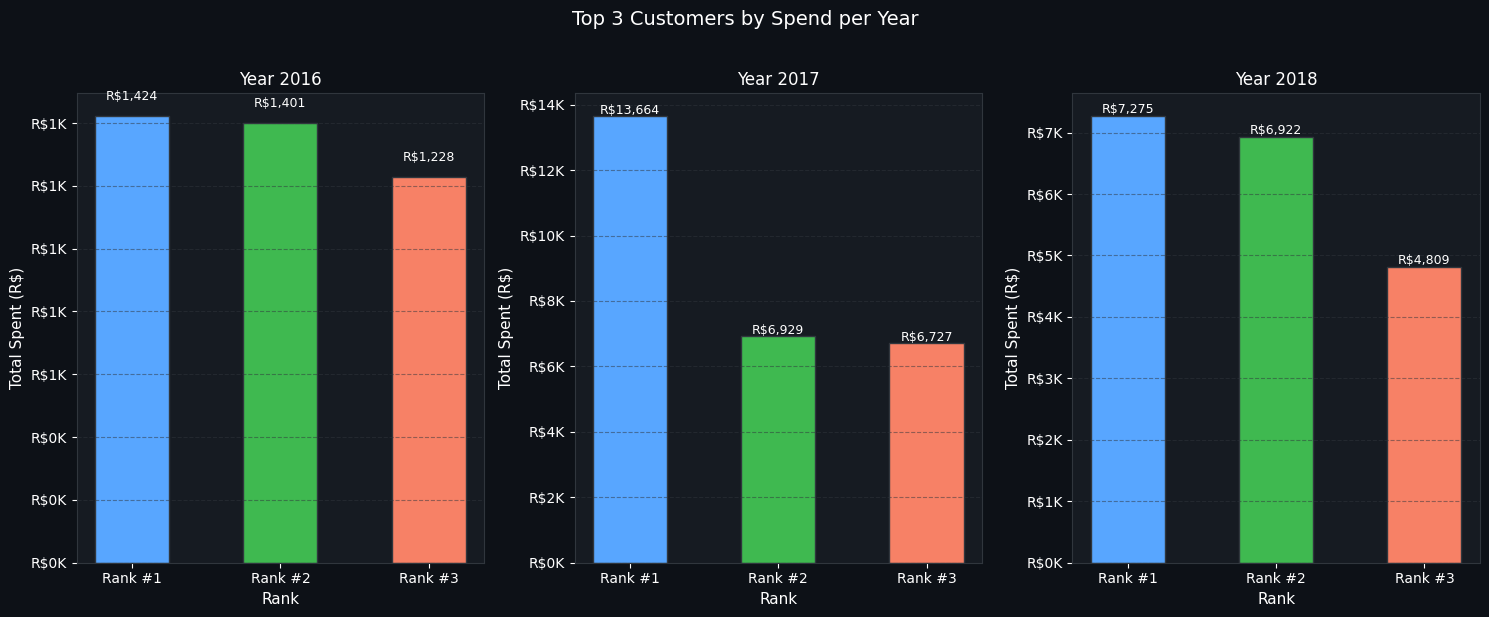

In [ ]:
customer_spend = (
    orders[["order_id","customer_id","order_purchase_timestamp"]]
    .merge(payments[["order_id","payment_value"]], on="order_id", how="left")
)
customer_spend["year"] = customer_spend["order_purchase_timestamp"].dt.year.astype("Int64")

yearly_customer_spend = (
    customer_spend.groupby(["year","customer_id"], as_index=False)["payment_value"]
    .sum().rename(columns={"payment_value":"total_spent"})
)
yearly_customer_spend["rank"] = (
    yearly_customer_spend.groupby("year")["total_spent"]
    .rank(method="min", ascending=False).astype(int)
)
top3 = (
    yearly_customer_spend[yearly_customer_spend["rank"] <= 3]
    .sort_values(["year","rank"]).reset_index(drop=True)
)
top3["label"] = "Rank #" + top3["rank"].astype(str)
top3["year"]  = top3["year"].astype(int)

years = sorted(top3["year"].unique())
fig, axes = plt.subplots(1, len(years), figsize=(5 * len(years), 6), sharey=False)

for ax, yr in zip(axes, years):
    df_yr = top3[top3["year"] == yr]
    bars  = ax.bar(df_yr["label"], df_yr["total_spent"],
                   color=COLORS[:3], edgecolor="#30363d", width=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'R${bar.get_height():,.0f}', ha='center', fontsize=9, color='white')
    ax.set_title(f"Year {yr}", fontsize=12)
    ax.set_xlabel("Rank")
    ax.set_ylabel("Total Spent (R$)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
    ax.grid(axis='y')
    ax.set_facecolor("#161b22")

fig.suptitle("Top 3 Customers by Spend per Year", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("top3_spenders.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()